# Método de Euler

Si se piensa en una ecuación diferencial como un campo de pendientes. La geometría sugiere que un enfoque alternativo de resolver computacionalmente la ecuación diferencial es siguiendo las feclas . Comience en la condición inicial $(t_0,y_0)$ y siga la dirección específicada allí. Despúes desplace una distancia corta, vuelva a evaluar la pendiente en el punto nuevo, aléjese aún más de acuerdo con la nueva pendiente y repita el proceso. Habá un error asociado con el proceso, puesto que, entre evaluaciones de la pendiente, no se moverá a lo largo de una pendiente totalmente exacta.

<center>

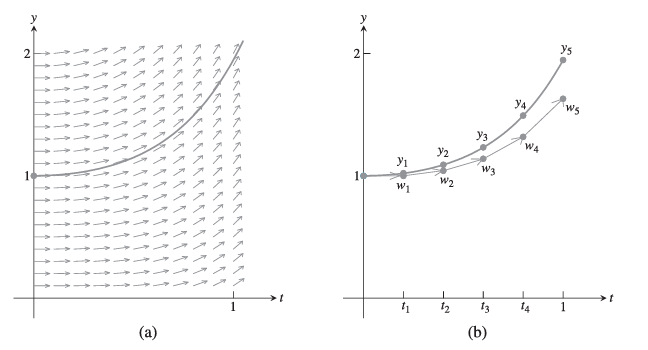

<center>

La aproximación es:

$$w_{i+1} = w_i + hf(t_i, w_i)$$

La fórmula para el método de Euler es entonces:

$$w_0 = y_0$$

$$w_{i+1} = w_i + hf(t_i, w_i)$$



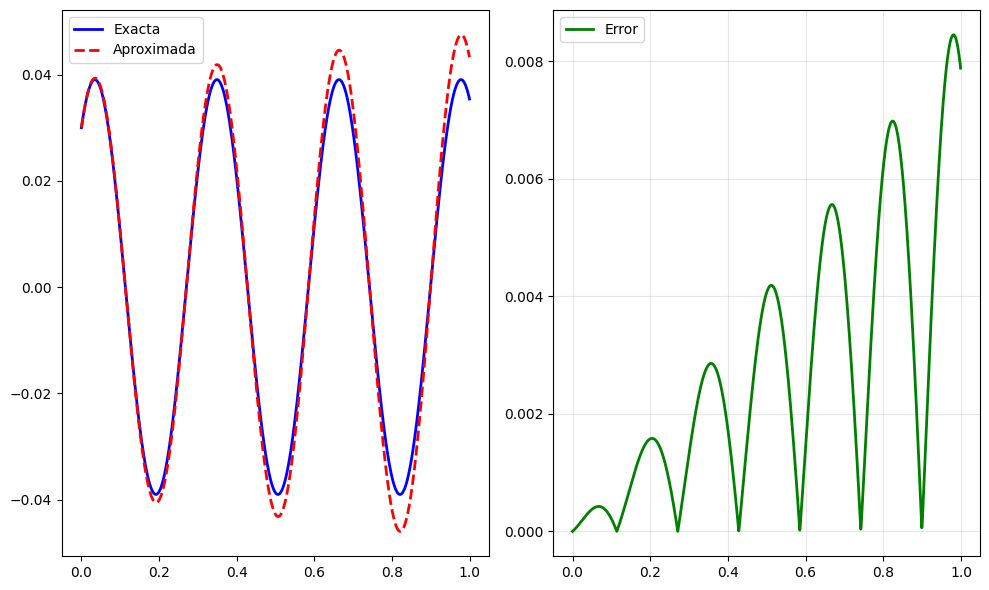

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sistema(Y0, t):
    Y1, Y2 = Y0
    DY1 = Y2
    DY2 = -(20)**2*Y1

    return np.array([DY1, DY2])

def Euler(sistema, a, b, h, Y0):

    t = np.arange(a, b, h)
    n = t.shape[0]
    Y = np.zeros((n, Y0.shape[0]))

    Y[0, :] = Y0

    for i in range(n-1):

        Y[i+1,:] = Y[i,:] + h*sistema(Y[i,:], t[i])

    return Y, t

Y0 = np.array([0.03, 0.5])

Y, t = Euler(sistema, 0, 1, 0.001, Y0)

def exacta(t):
    return 0.03*np.cos(20*t) + (0.5/20)*np.sin(20*t)

Y_e = exacta(t)

error = np.abs(Y[:,0] - Y_e)

fig, ax = plt.subplots(1,2,figsize = (10,6))

ax[0].plot(t, Y_e, c = 'blue', lw = 2, label = 'Exacta')
ax[0].plot(t, Y[:,0], c = 'red', lw = 2, ls = '--', label = 'Aproximada')
ax[0].legend()

ax[1].plot(t, error, c = 'green', lw = 2, label = 'Error')
ax[1].legend()

ax[1].grid(alpha = 0.3)
plt.tight_layout()
plt.show()



